In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

Text(0, 0.5, 'Y dataset')

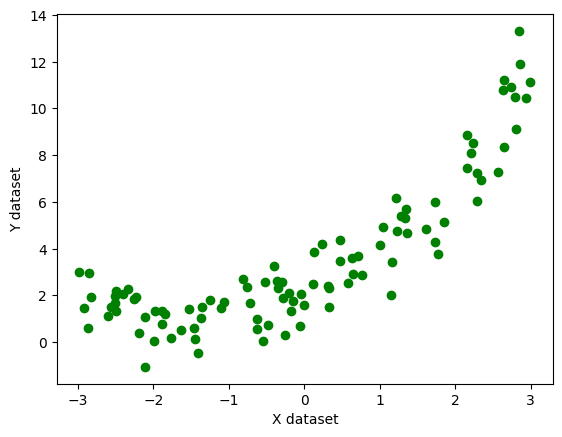

In [108]:
X = 6* np.random.rand(100,1)-3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100,1)
# quadratic quation used - y = 0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color = 'g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [109]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [110]:
## lets implement a simple linear regression 
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [111]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [112]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression_1.predict(X_test))
print(score)

0.7344217033733933


Text(0, 0.5, 'Y')

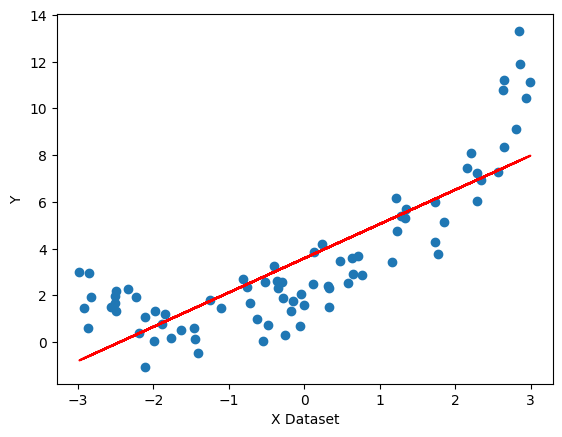

In [113]:
## Lets visualize the model
plt.plot(X_train, regression_1.predict(X_train), color = 'r')
plt.scatter(X_train, y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")

In [114]:
# Lets apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [115]:
poly = PolynomialFeatures(degree = 2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [116]:
X_train_poly

array([[ 1.00000000e+00,  7.67794010e-01,  5.89507641e-01],
       [ 1.00000000e+00, -2.97950030e+00,  8.87742204e+00],
       [ 1.00000000e+00, -2.18574351e+00,  4.77747469e+00],
       [ 1.00000000e+00,  1.21183834e+00,  1.46855215e+00],
       [ 1.00000000e+00, -2.49546320e+00,  6.22733659e+00],
       [ 1.00000000e+00, -1.63073871e+00,  2.65930873e+00],
       [ 1.00000000e+00, -2.82822898e+00,  7.99887917e+00],
       [ 1.00000000e+00,  1.29994415e-01,  1.68985480e-02],
       [ 1.00000000e+00, -2.11667329e+00,  4.48030582e+00],
       [ 1.00000000e+00, -1.25602666e+00,  1.57760297e+00],
       [ 1.00000000e+00, -4.45164589e-02,  1.98171511e-03],
       [ 1.00000000e+00,  2.85461013e+00,  8.14879899e+00],
       [ 1.00000000e+00,  2.14909236e+00,  4.61859797e+00],
       [ 1.00000000e+00, -1.40645396e+00,  1.97811275e+00],
       [ 1.00000000e+00, -2.33559569e+00,  5.45500721e+00],
       [ 1.00000000e+00, -2.49470009e+00,  6.22352853e+00],
       [ 1.00000000e+00, -2.85802659e+00

In [117]:
X_test_poly

array([[ 1.        ,  2.79337703,  7.80295521],
       [ 1.        , -2.40871937,  5.80192899],
       [ 1.        , -0.19741875,  0.03897416],
       [ 1.        ,  1.61704001,  2.61481838],
       [ 1.        , -1.52649174,  2.33017703],
       [ 1.        ,  1.14381939,  1.30832279],
       [ 1.        , -2.25467306,  5.08355062],
       [ 1.        ,  2.22917979,  4.96924254],
       [ 1.        , -1.05960125,  1.12275482],
       [ 1.        ,  2.74404169,  7.52976477],
       [ 1.        ,  1.35553844,  1.83748447],
       [ 1.        , -2.60701816,  6.79654369],
       [ 1.        , -1.36232125,  1.85591919],
       [ 1.        , -1.36224541,  1.85571255],
       [ 1.        ,  0.46647563,  0.21759951],
       [ 1.        ,  1.04053991,  1.0827233 ],
       [ 1.        ,  2.15743376,  4.65452042],
       [ 1.        ,  0.99804428,  0.99609239],
       [ 1.        , -0.62893483,  0.39555902],
       [ 1.        , -1.87922548,  3.53148842]])

In [118]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.9210898480895099


In [120]:
print(regression.coef_)

[[0.         1.46628062 0.49640888]]


In [121]:
print(regression.intercept_)

[2.03327004]


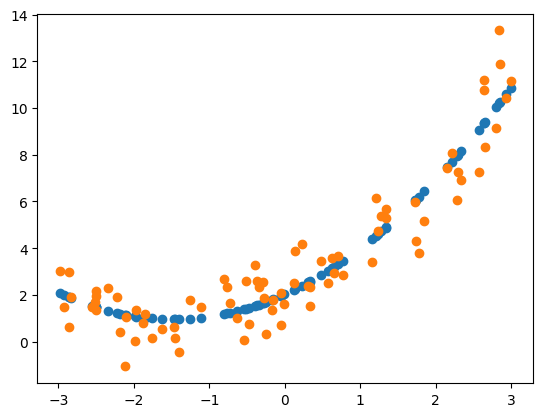

In [122]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

In [123]:
poly = PolynomialFeatures(degree = 3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [124]:
X_train_poly

array([[ 1.00000000e+00,  7.67794010e-01,  5.89507641e-01,
         4.52620436e-01],
       [ 1.00000000e+00, -2.97950030e+00,  8.87742204e+00,
        -2.64502816e+01],
       [ 1.00000000e+00, -2.18574351e+00,  4.77747469e+00,
        -1.04423343e+01],
       [ 1.00000000e+00,  1.21183834e+00,  1.46855215e+00,
         1.77964780e+00],
       [ 1.00000000e+00, -2.49546320e+00,  6.22733659e+00,
        -1.55400893e+01],
       [ 1.00000000e+00, -1.63073871e+00,  2.65930873e+00,
        -4.33663768e+00],
       [ 1.00000000e+00, -2.82822898e+00,  7.99887917e+00,
        -2.26226619e+01],
       [ 1.00000000e+00,  1.29994415e-01,  1.68985480e-02,
         2.19671687e-03],
       [ 1.00000000e+00, -2.11667329e+00,  4.48030582e+00,
        -9.48334365e+00],
       [ 1.00000000e+00, -1.25602666e+00,  1.57760297e+00,
        -1.98151139e+00],
       [ 1.00000000e+00, -4.45164589e-02,  1.98171511e-03,
        -8.82189392e-05],
       [ 1.00000000e+00,  2.85461013e+00,  8.14879899e+00,
      

In [125]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test,y_pred)
print(score)

0.9252067142198819


In [127]:
# prediction of new data set
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

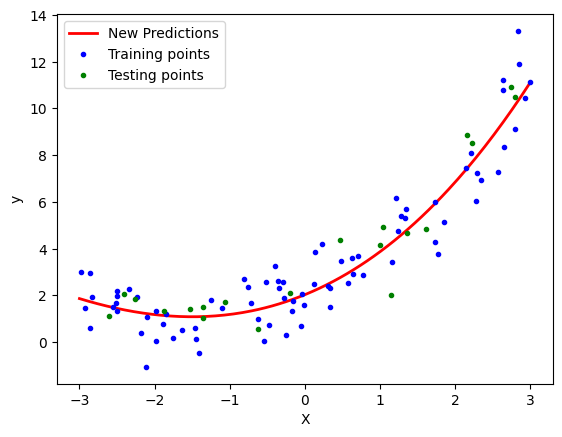

In [129]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label = "New Predictions")
plt.plot(X_train, y_train, "b.", label= 'Training points')
plt.plot(X_test, y_test, "g.", label= 'Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

Pipeline Concepts

In [132]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def poly_regression(degree):
    X_new = np.linspace(-3,3,200).reshape(200,1)

    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("line_reg", lin_reg)
    ])

    poly_regression.fit(X_train, y_train) ## polynomial and fit of linear regression
    y_pred_new = poly_regression.predict(X_new)
    # plotting prediction line
    plt.plot(X_new, y_pred_new, 'r', label = "Degree" + str(degree), linewidth = 2)
    plt.plot(X_train, y_train, "b.", linewidth =3)
    plt.plot(X_test,y_test, "g.", linewidth = 3)
    plt.legend(loc = "upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4,0,10])
    plt.show()



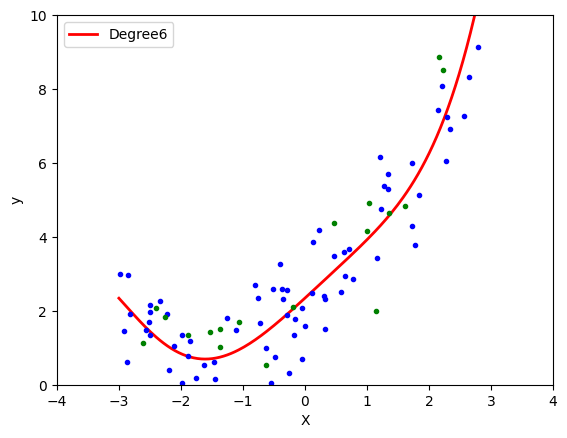

In [133]:
poly_regression(6)